# 14 -- Compositional feasibility (Stage 7.0)

Gate for the [PLAN_Compositional.md](../PLAN_Compositional.md) Stage 7a-7e investment.
Tests whether **boulder-rich HiRISE pixels differ spectrally from their immediate
surroundings** at the per-polygon (Test A) and per-tile (Test B) scales, using
*truth* BoulderNet polygons (not model predictions) on a 3-image trio.

**Trio (as locked-in 2026-05-31)**:
- `ESP_042964_2160` -- high-density positive (model AUC 0.91)
- `ESP_054000_2255` -- anti-signal #1 (model AUC 0.40, anti-correlated)
- `ESP_055253_2245` -- anti-signal #2 (model AUC 0.42), substituted for the
  original `ESP_055978_2270` which has no PDS `COLOR.JP2`

This notebook RENDERS the probe outputs at
[`cache_v2/stage7/`](../cache_v2/stage7) -- it does not re-extract spectra.
Re-run the probe via:

```powershell
& "C:/Users/brian/anaconda3/Scripts/conda.exe" run --no-capture-output -n geospatial `
    python -u scripts/probes/_stage7_feasibility.py
```

Probe runtime is ~3-10 min on cached COLOR.JP2s.


## 1. Setup + per-image overview

Cache layout (under `cache_v2/`):
- `hirise_color/{ObsId}_COLOR.JP2` + `.LBL` -- the colour rasters and labels
  (downloaded by `scripts/probes/_fetch_color.py`)
- `reprojected_detections/{ObsId}.json` -- Stage 1 SP1-corrected source CRS,
  reused to override the buggy CRS the COLOR.JP2 reports
- `stage7/test_a_per_polygon_{ObsId}.parquet` -- per-polygon paired spectra
- `stage7/test_b_per_tile_{ObsId}.parquet` -- per-tile spectra + truth labels
- `stage7/{test_a,test_b}_summary.parquet` -- per-image, per-feature statistics


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sst

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from src import colour  # noqa: E402

CACHE = ROOT / "cache_v2"
STAGE7 = CACHE / "stage7"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

TRIO = ["ESP_042964_2160", "ESP_054000_2255", "ESP_055253_2245"]
ROLES = {
    "ESP_042964_2160": "high-density positive (AUC 0.91)",
    "ESP_054000_2255": "anti-signal #1 (AUC 0.40)",
    "ESP_055253_2245": "anti-signal #2 (AUC 0.42)",
}

# Load per-image LBL metadata
overview = []
for obs in TRIO:
    lbl = colour.parse_color_lbl(colour.color_lbl_path(CACHE, obs))
    overview.append({
        "obs_id": obs, "role": ROLES[obs],
        "incidence_deg": lbl.incidence_deg, "cos_i": lbl.cos_incidence,
        "emission_deg": lbl.emission_deg, "phase_deg": lbl.phase_deg,
        "solar_longitude_deg": lbl.solar_longitude_deg,
        "map_scale_mpp": lbl.map_scale_mpp,
        "swath_size_px": f"{lbl.lines} x {lbl.line_samples}",
        "swath_width_m": round(lbl.line_samples * lbl.map_scale_mpp),
    })
overview_df = pd.DataFrame(overview)
overview_df


,obs_id,role,incidence_deg,cos_i,emission_deg,phase_deg,solar_longitude_deg,map_scale_mpp,swath_size_px,swath_width_m
0,ESP_042964_2160,high-density positive (AUC 0.91),40.667169,0.758508,2.231420,38.547409,46.649925,0.25,41757 x 9531,2383
1,ESP_054000_2255,anti-signal #1 (AUC 0.40),45.570460,0.700032,6.251890,39.525790,123.698048,0.50,24412 x 5142,2571
2,ESP_055253_2245,anti-signal #2 (AUC 0.42),60.259586,0.496071,0.395156,60.460656,173.441359,0.25,36639 x 9776,2444


## 2. Test A -- per-polygon paired spectra

For each boulder polygon (within the colour swath), we extract the per-band mean
I/F **inside the polygon** and in a **2-10 m outward buffer ring**, excluding the
polygon interior. Then we test whether `interior_band` differs from `ring_band`
using a paired Wilcoxon signed-rank test, and report Cohen's d (paired) on the
diff distribution.

**Lambertian correction note** (per PLAN section 5.3, 2026-05-31 update):
`I/F_corrected = I/F_obs / cos(i)` is a multiplicative constant per image. It
cancels in (interior - ring) differences AND in all band ratios -- so the Test A
results below are Lambertian-invariant within each image, even though they are
raw I/F values.

The PLAN section 3.1 pass condition (per Test A) is:
- significant difference in **at least one** of {IR, RED, BG, IR/BG, IR/RED,
  dust_index = RED/BG} in **at least one** image (Wilcoxon `p < 0.05`,
  `|d| > 0.3`).


In [2]:
# Load per-image Test A spectra + summary
per_polygon = pd.concat(
    [pd.read_parquet(STAGE7 / f"test_a_per_polygon_{obs}.parquet") for obs in TRIO],
    ignore_index=True,
)
summary_a = pd.read_parquet(STAGE7 / "test_a_summary.parquet")
summary_a_display = (
    summary_a
    .pivot_table(index="feature",
                 columns="obs_id",
                 values=["mean_diff", "cohens_d_paired", "wilcoxon_p"],
                 aggfunc="first")
)
print(f"Total polygons across the trio: {len(per_polygon)}")
print(f"Per-image:")
print(per_polygon["obs_id"].value_counts())
summary_a_display


Total polygons across the trio: 975
Per-image:
obs_id
ESP_055253_2245    362
ESP_054000_2255    354
ESP_042964_2160    259
Name: count, dtype: int64


cohens_d_paired                                  \
obs_id                 ESP_042964_2160 ESP_054000_2255 ESP_055253_2245   
feature                                                                  
BG                           -1.718586       -0.408980        0.230400   
IR                           -2.164906       -0.695234       -0.082788   
IR_over_BG                    0.943185        0.046042       -0.340889   
IR_over_RED                   1.275443       -0.194362       -0.713085   
RED                          -2.233841       -0.696435        0.112512   
dust_index_RED_over_BG        0.767355        0.086030       -0.222216   

                             mean_diff                                  \
obs_id                 ESP_042964_2160 ESP_054000_2255 ESP_055253_2245   
feature                                                                  
BG                          -19.694722       -6.059749        3.059982   
IR                          -78.885787      -32.405349       -2.723559   
IR_over_BG                    0.398032        0.022657       -0.157921   
IR_over_RED                   0.017166       -0.004327       -0.012375   
RED                         -78.915407      -28.802805        3.817817   
dust_index_RED_over_BG        0.266070        0.035510       -0.092098   

                            wilcoxon_p                                  
obs_id                 ESP_042964_2160 ESP_054000_2255 ESP_055253_2245  
feature                                                                 
BG                        2.246929e-43    2.102536e-12    1.173472e-05  
IR                        3.297926e-44    3.694514e-28    4.783913e-02  
IR_over_BG                2.516395e-34    8.175516e-01    1.846467e-12  
IR_over_RED               3.401585e-38    8.992159e-04    1.652792e-30  
RED                       3.336457e-44    3.199008e-28    4.795231e-02  
dust_index_RED_over_BG    1.157764e-27    6.488058e-01    3.393025e-07

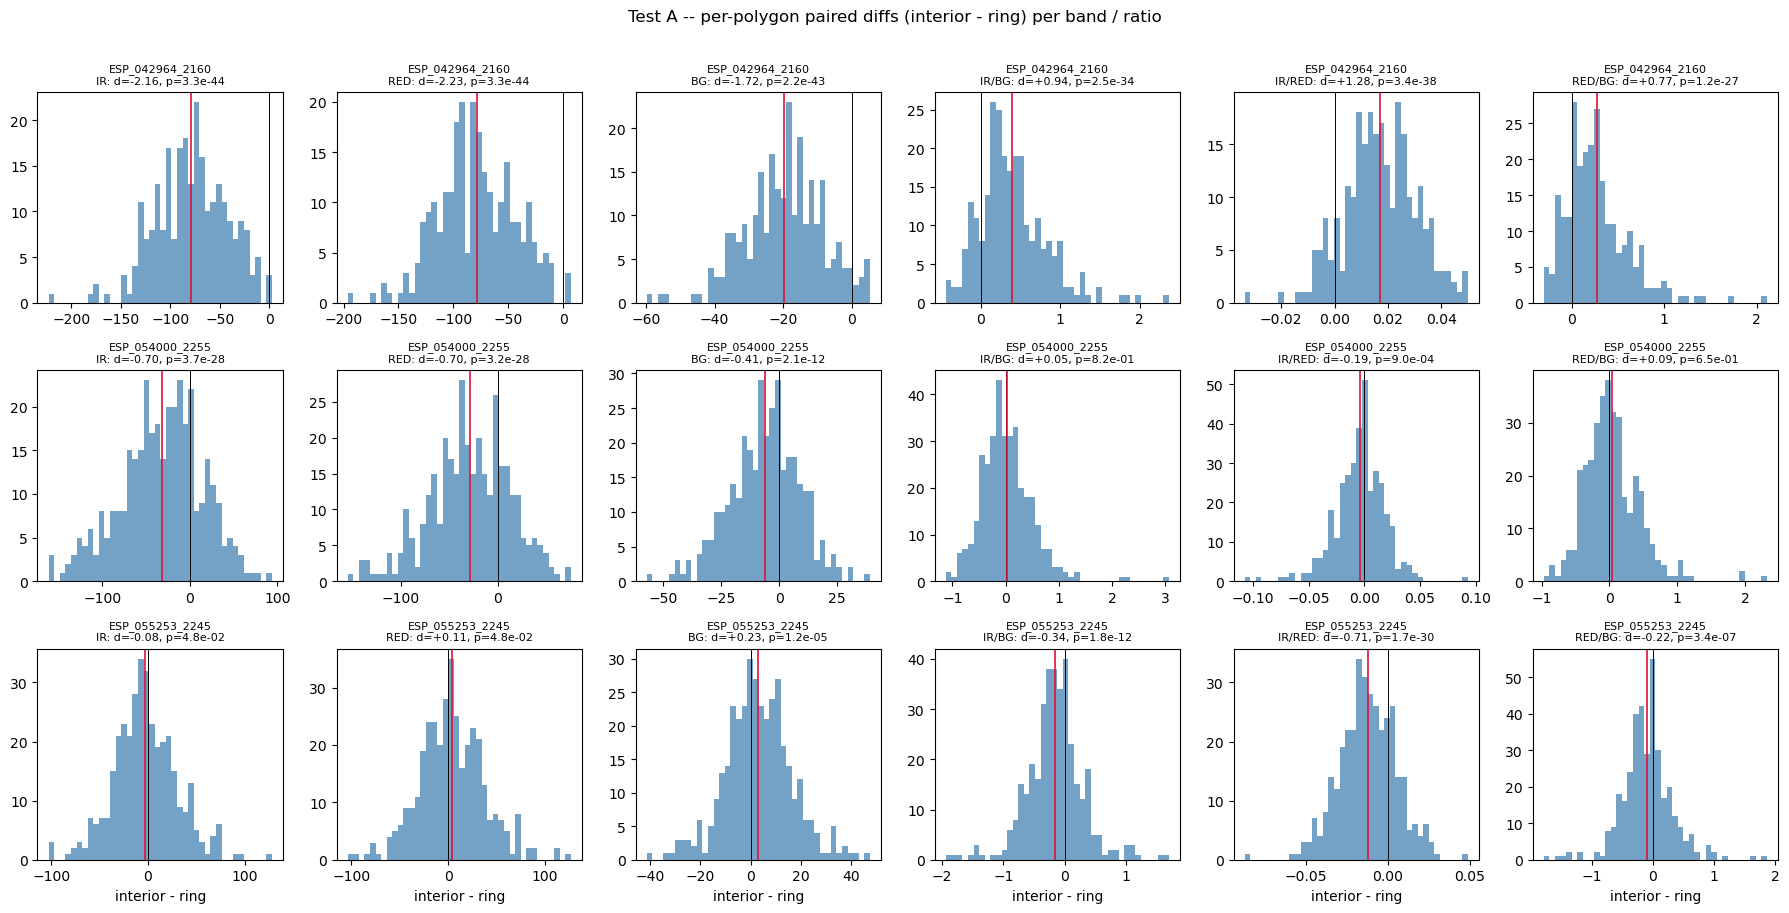

In [3]:
# Visualise the paired diff distribution per band x ObsId
fig, axes = plt.subplots(3, 6, figsize=(18, 9), sharex=False)
bands = ["IR", "RED", "BG", "IR/BG", "IR/RED", "RED/BG"]
for r, obs in enumerate(TRIO):
    sub = per_polygon[per_polygon["obs_id"] == obs]
    if sub.empty:
        for c, _ in enumerate(bands):
            axes[r, c].text(0.5, 0.5, "no data", transform=axes[r, c].transAxes, ha="center")
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        continue
    for c, band in enumerate(bands):
        if "/" in band:
            num, den = band.split("/")
            diffs = (sub[f"{num}_in"] / sub[f"{den}_in"]
                     - sub[f"{num}_ring"] / sub[f"{den}_ring"]).dropna()
        else:
            diffs = (sub[f"{band}_in"] - sub[f"{band}_ring"]).dropna()
        ax = axes[r, c]
        ax.hist(diffs, bins=40, color="steelblue", alpha=0.75)
        ax.axvline(0, color="k", linewidth=0.7)
        ax.axvline(diffs.mean(), color="crimson", linewidth=1.2,
                   label=f"mean={diffs.mean():+.4f}")
        try:
            _, p = sst.wilcoxon(diffs)
        except ValueError:
            p = float("nan")
        d = diffs.mean() / (diffs.std(ddof=1) or 1)
        ax.set_title(f"{obs}\n{band}: d={d:+.2f}, p={p:.1e}", fontsize=8)
        if r == len(TRIO) - 1:
            ax.set_xlabel("interior - ring")
fig.suptitle("Test A -- per-polygon paired diffs (interior - ring) per band / ratio",
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG / "stage7_test_a_paired_diffs.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Test B -- per-tile @ S=64, boulder-rich vs boulder-poor truth partition

For each 320 m (`S=64` CTX-pixel) tile, we extract the mean COLOR.JP2 I/F per band
within the tile bounds (after reprojection from CTX CRS to the SP1-corrected source
CRS). Tiles are partitioned by the truth label `fa_gt_1e-2` -- i.e. tiles whose
HiRISE-derived `fractional_area >= 1e-2` are "boulder-rich".

Two-sample Mann-Whitney U + Cohen's d (unpaired) per band/ratio.


In [4]:
per_tile = pd.concat(
    [pd.read_parquet(STAGE7 / f"test_b_per_tile_{obs}.parquet") for obs in TRIO],
    ignore_index=True,
)
summary_b = pd.read_parquet(STAGE7 / "test_b_summary.parquet")
summary_b_display = (
    summary_b
    .pivot_table(index="feature",
                 columns="obs_id",
                 values=["mean_rich", "mean_poor", "cohens_d", "mannwhitney_p"],
                 aggfunc="first")
)
print(f"Per-image S=64 tile counts (in swath):")
print(per_tile.groupby("obs_id").size())
print(f"\nRich vs poor counts (fa >= 1e-2):")
print(per_tile.assign(rich=per_tile["fractional_area"] >= 1e-2)
      .groupby(["obs_id", "rich"]).size().unstack(fill_value=0))
summary_b_display


Per-image S=64 tile counts (in swath):
obs_id
ESP_042964_2160    146
ESP_054000_2255    223
ESP_055253_2245    173
dtype: int64

Rich vs poor counts (fa >= 1e-2):
rich             False  True 
obs_id                       
ESP_042964_2160    141      5
ESP_054000_2255    177     46
ESP_055253_2245    165      8


cohens_d                                  \
obs_id                 ESP_042964_2160 ESP_054000_2255 ESP_055253_2245   
feature                                                                  
BG                           -0.151893       -0.248327       -0.247679   
IR                            0.303210       -0.184418        0.220353   
IR_over_BG                    0.864715        0.208916        1.232042   
IR_over_RED                   0.579782       -0.187191        0.458136   
RED                           0.257466       -0.184084        0.141838   
dust_index_RED_over_BG        0.799866        0.309057        1.092690   

                         mannwhitney_p       mean_poor                  \
obs_id                 ESP_054000_2255 ESP_042964_2160 ESP_054000_2255   
feature                                                                  
BG                            0.160205      132.628226      128.094555   
IR                            0.505642      786.529467      613.531503   
IR_over_BG                    0.062388        5.932111        4.797774   
IR_over_RED                   0.411015        1.128845        1.059500   
RED                           0.490997      696.699041      578.758279   
dust_index_RED_over_BG        0.011729        5.254942        4.528081   

                                             mean_rich                  \
obs_id                 ESP_055253_2245 ESP_042964_2160 ESP_054000_2255   
feature                                                                  
BG                          116.723484      131.917772      125.036493   
IR                          553.270666      793.754594      603.770908   
IR_over_BG                    4.757664        6.018280        4.831718   
IR_over_RED                   1.030557        1.131340        1.057149   
RED                         536.621511      701.586853      570.508759   
dust_index_RED_over_BG        4.617101        5.319663        4.570527   

                                        
obs_id                 ESP_055253_2245  
feature                                 
BG                          113.570082  
IR                          562.597758  
IR_over_BG                    5.040272  
IR_over_RED                   1.035529  
RED                         541.782555  
dust_index_RED_over_BG        4.875727

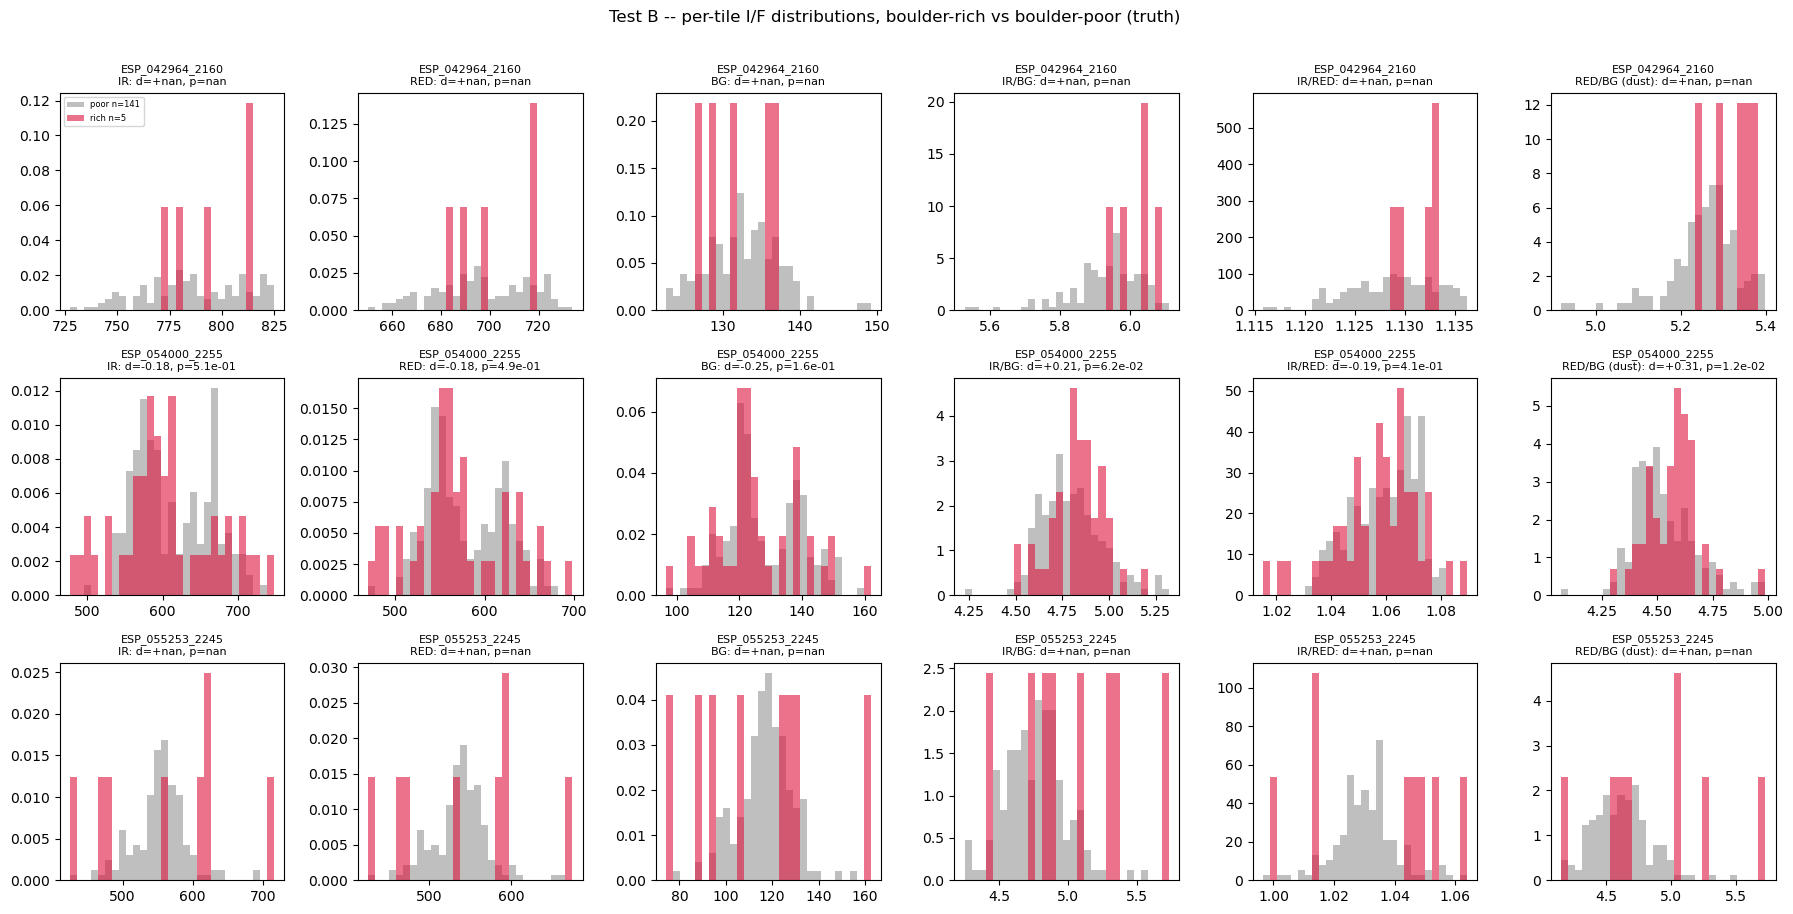

In [5]:
# Boulder-rich vs boulder-poor I/F distributions per band x ObsId
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
features = [
    ("IR", lambda d: d["IR"]),
    ("RED", lambda d: d["RED"]),
    ("BG", lambda d: d["BG"]),
    ("IR/BG", lambda d: d["IR"] / d["BG"]),
    ("IR/RED", lambda d: d["IR"] / d["RED"]),
    ("RED/BG (dust)", lambda d: d["RED"] / d["BG"]),
]
for r, obs in enumerate(TRIO):
    sub = per_tile[per_tile["obs_id"] == obs]
    rich = sub[sub["fractional_area"] >= 1e-2]
    poor = sub[sub["fractional_area"] < 1e-2]
    for c, (name, fn) in enumerate(features):
        ax = axes[r, c]
        try:
            r_vals = fn(rich).dropna()
            p_vals = fn(poor).dropna()
            if len(r_vals) and len(p_vals):
                lo = min(r_vals.min(), p_vals.min())
                hi = max(r_vals.max(), p_vals.max())
                bins = np.linspace(lo, hi, 30)
                ax.hist(p_vals, bins=bins, alpha=0.5, label=f"poor n={len(p_vals)}",
                        color="grey", density=True)
                ax.hist(r_vals, bins=bins, alpha=0.6, label=f"rich n={len(r_vals)}",
                        color="crimson", density=True)
                # Stats
                if len(r_vals) >= 10 and len(p_vals) >= 10:
                    u, p_val = sst.mannwhitneyu(r_vals, p_vals)
                    na, nb = len(r_vals), len(p_vals)
                    pooled = np.sqrt(((na-1)*r_vals.var(ddof=1)
                                      + (nb-1)*p_vals.var(ddof=1)) / (na+nb-2))
                    d = (r_vals.mean() - p_vals.mean()) / (pooled or 1)
                else:
                    p_val = float("nan"); d = float("nan")
                ax.set_title(f"{obs}\n{name}: d={d:+.2f}, p={p_val:.1e}", fontsize=8)
        except Exception as e:
            ax.text(0.5, 0.5, f"err: {e}", transform=ax.transAxes, fontsize=6)
        if r == 0 and c == 0:
            ax.legend(fontsize=6)
fig.suptitle("Test B -- per-tile I/F distributions, boulder-rich vs boulder-poor (truth)",
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIG / "stage7_test_b_rich_vs_poor.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Dust-confound discriminator (PLAN section 5)

A spectral difference between boulder-rich and boulder-poor regions has TWO competing
explanations: (i) **composition** (different mineralogy of the boulders vs the
surrounding regolith) or (ii) **dust** (boulder-rich areas have less dust accumulation,
shifting them bluer in IRB).

The PLAN section 5.1 dust proxy is `dust_index = RED / BG` (higher = more dust). The
PLAN section 5.2 procedure: (a) test boulder-rich vs boulder-poor on `dust_index`,
(b) test on `IR/BG` and `IR/RED`, (c) **partial-correlate** the IR/BG difference with
`dust_index` to see if it survives.

We do the partial-correlation analysis on the Test B per-tile data (more direct
sample-size match to the boulder-rich/boulder-poor partition). The Test A polygon
data gives a similar within-image analysis for free.


In [6]:
def partial_corr(x, y, z):
    """Partial correlation of x and y controlling for z (Pearson on residuals)."""
    x = np.asarray(x); y = np.asarray(y); z = np.asarray(z)
    m = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))
    x, y, z = x[m], y[m], z[m]
    if len(x) < 3:
        return float("nan"), float("nan")
    # OLS residuals
    bx = np.polyfit(z, x, 1); rx = x - np.polyval(bx, z)
    by = np.polyfit(z, y, 1); ry = y - np.polyval(by, z)
    r, p = sst.pearsonr(rx, ry)
    return float(r), float(p)


rows = []
for obs in TRIO:
    sub = per_tile[per_tile["obs_id"] == obs].copy()
    if sub.empty:
        continue
    sub["rich"] = (sub["fractional_area"] >= 1e-2).astype(int)
    sub["dust_index"] = sub["RED"] / sub["BG"]
    sub["IR_over_BG"] = sub["IR"] / sub["BG"]
    sub["IR_over_RED"] = sub["IR"] / sub["RED"]

    # (a) rich vs poor on dust_index
    rich_dust = sub.loc[sub["rich"] == 1, "dust_index"].dropna()
    poor_dust = sub.loc[sub["rich"] == 0, "dust_index"].dropna()
    if len(rich_dust) >= 10 and len(poor_dust) >= 10:
        _, p_dust = sst.mannwhitneyu(rich_dust, poor_dust)
        pooled = np.sqrt(((len(rich_dust)-1) * rich_dust.var(ddof=1)
                          + (len(poor_dust)-1) * poor_dust.var(ddof=1))
                         / (len(rich_dust) + len(poor_dust) - 2))
        d_dust = (rich_dust.mean() - poor_dust.mean()) / (pooled or 1)
    else:
        p_dust = d_dust = float("nan")

    # (b) marginal correlation of `rich` (1/0) with IR/BG and IR/RED
    r_irbg, p_irbg = sst.pointbiserialr(sub["rich"], sub["IR_over_BG"])
    r_irred, p_irred = sst.pointbiserialr(sub["rich"], sub["IR_over_RED"])

    # (c) partial correlation of `rich` with IR/BG (and IR/RED) controlling for dust_index
    pr_irbg, pp_irbg = partial_corr(sub["rich"], sub["IR_over_BG"], sub["dust_index"])
    pr_irred, pp_irred = partial_corr(sub["rich"], sub["IR_over_RED"], sub["dust_index"])
    rows.append({
        "obs_id": obs,
        "dust_d_rich_vs_poor": round(d_dust, 3), "dust_p": p_dust,
        "marginal_r_IRoverBG": round(r_irbg, 3), "marg_p_IRoverBG": p_irbg,
        "partial_r_IRoverBG|dust": round(pr_irbg, 3), "partial_p_IRoverBG|dust": pp_irbg,
        "marginal_r_IRoverRED": round(r_irred, 3), "marg_p_IRoverRED": p_irred,
        "partial_r_IRoverRED|dust": round(pr_irred, 3), "partial_p_IRoverRED|dust": pp_irred,
    })
dust_df = pd.DataFrame(rows)
dust_df.to_parquet(STAGE7 / "dust_summary.parquet")
dust_df


,obs_id,dust_d_rich_vs_poor,dust_p,marginal_r_IRoverBG,marg_p_IRoverBG,partial_r_IRoverBG|dust,partial_p_IRoverBG|dust,marginal_r_IRoverRED,marg_p_IRoverRED,partial_r_IRoverRED|dust,partial_p_IRoverRED|dust
0,ESP_042964_2160,NaN,NaN,0.156,0.059411,0.070,0.403878,0.106,0.204702,0.069,0.409322
1,ESP_054000_2255,0.309,0.011729,0.085,0.208147,-0.094,0.160400,-0.076,0.259242,-0.091,0.174266
2,ESP_055253_2245,NaN,NaN,0.252,0.000830,0.159,0.036814,0.096,0.207417,0.183,0.015981


## 5. Go / no-go decision against PLAN section 3.1 pass conditions

Pass conditions:

- **(a) Pass**: at least one image shows a statistically significant boulder-vs-
  surroundings difference (`p < 0.05`, `|d| > 0.3`) in **at least one** of
  IR/RED/BG or a band ratio, in **at least one of Test A or Test B**, AND the
  dust-confound test returns an interpretable result.
- **(b) Conditional pass**: significant differences but fully attributable to
  dust (partial correlation washes out the IR/BG signal).
- **(c) Fail**: no significant difference on truth labels.

The cell below computes the pass status from the loaded summaries and prints the
verdict. **Final write-up of the decision goes into [DECISIONS.md](../DECISIONS.md)**
once Brian signs off.


In [7]:
# Pass criterion: p < 0.05 AND |d| > 0.3 anywhere in Test A or Test B
THRESH_P = 0.05
THRESH_D = 0.3

def passes(df, p_col, d_col):
    if df.empty:
        return df
    return df[(df[p_col] < THRESH_P) & (df[d_col].abs() > THRESH_D)]

passing_a = passes(summary_a, "wilcoxon_p", "cohens_d_paired")
passing_b = passes(summary_b, "mannwhitney_p", "cohens_d")

print("=== Test A passing (feature, ObsId): ===")
if not passing_a.empty:
    print(passing_a[["obs_id", "feature", "n_pairs", "mean_diff",
                     "cohens_d_paired", "wilcoxon_p"]].to_string(index=False))
else:
    print("  none")

print("\n=== Test B passing (feature, ObsId): ===")
if not passing_b.empty:
    print(passing_b[["obs_id", "feature", "n_rich", "n_poor",
                     "mean_rich", "mean_poor",
                     "cohens_d", "mannwhitney_p"]].to_string(index=False))
else:
    print("  none")

# Now interpret with dust confound
any_pass = (not passing_a.empty) or (not passing_b.empty)
print(f"\nPLAN 3.1 (a) pass condition met (p<{THRESH_P}, |d|>{THRESH_D}, "
      f"any feature, any test, any image): {any_pass}")

# Dust-confound result: did `partial_r_IRoverBG|dust` lose significance?
if "partial_p_IRoverBG|dust" in dust_df.columns:
    survived = dust_df[(dust_df["partial_p_IRoverBG|dust"] < 0.05)
                       & (dust_df["partial_r_IRoverBG|dust"].abs() > 0.1)]
    print(f"\nDust-controlled IR/BG signal survives in {len(survived)}/{len(dust_df)} images:")
    print(dust_df[["obs_id", "marginal_r_IRoverBG", "partial_r_IRoverBG|dust",
                   "partial_p_IRoverBG|dust"]].to_string(index=False))

# Final verdict string
if any_pass:
    if "partial_p_IRoverBG|dust" in dust_df.columns and not survived.empty:
        verdict = "PASS (a) -- composition signal detected (dust-controlled)"
    elif "partial_p_IRoverBG|dust" in dust_df.columns:
        verdict = "CONDITIONAL PASS (b) -- signal fully dust-attributable (relative age, not composition)"
    else:
        verdict = "PASS (a) -- signal detected; dust analysis inconclusive"
else:
    verdict = "FAIL (c) -- no significant boulder-vs-surroundings signal"
print(f"\n>>> VERDICT: {verdict}")


=== Test A passing (feature, ObsId): ===
         obs_id                feature  n_pairs  mean_diff  cohens_d_paired   wilcoxon_p
ESP_042964_2160                     IR      259 -78.885787        -2.164906 3.297926e-44
ESP_042964_2160                    RED      259 -78.915407        -2.233841 3.336457e-44
ESP_042964_2160                     BG      259 -19.694722        -1.718586 2.246929e-43
ESP_042964_2160             IR_over_BG      259   0.398032         0.943185 2.516395e-34
ESP_042964_2160            IR_over_RED      259   0.017166         1.275443 3.401585e-38
ESP_042964_2160 dust_index_RED_over_BG      259   0.266070         0.767355 1.157764e-27
ESP_054000_2255                     IR      354 -32.405349        -0.695234 3.694514e-28
ESP_054000_2255                    RED      354 -28.802805        -0.696435 3.199008e-28
ESP_054000_2255                     BG      354  -6.059749        -0.408980 2.102536e-12
ESP_055253_2245             IR_over_BG      362  -0.157921        -0.